> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API and this case's dependencies
%pip install -q coptpy numpy pandas


In [ ]:
# This case needs data files. Colab opens the notebook alone, so fetch them here.
import os, urllib.parse, urllib.request
BASE = 'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/notebooks/Risk_Parity_model/'
FILES = [
    'return_sample.csv',
]
for f in FILES:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or '.', exist_ok=True)
        urllib.request.urlretrieve(BASE + urllib.parse.quote(f), f)
print(len(FILES), 'data file(s) ready')


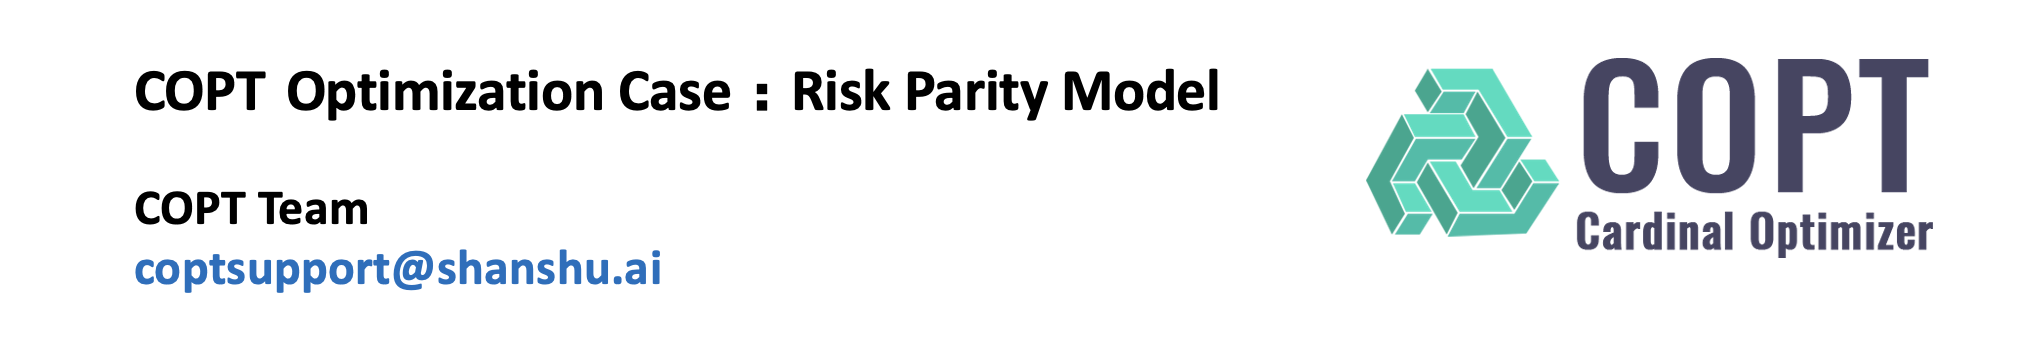

# Code Implementation

## Steps for Optimizing a Conic Programming Problem

The basic steps to model and solve cone programming problems using COPT in Python are as follows:

1. Import the `coptpy` package

2. Add/import model test **data**

3. Create a **COPT environment** and a **COPT model**

4. Build the model by adding the **three essential elements**:
    - Add **decision variables**: integer (or binary) and continuous
    - Set the **objective function**: In this case, we transform the quadratic terms and exponential cone terms in the original objective into constraints by introducing auxiliary variables
    - Add **constraints**: add quadratic constraints and exponential cone constraints

5. **Solve** the model

6. View and analyze the **results**


## Add Test Data of the model

The return rate data for the top 50 stocks with the highest proportion in the S&P 500 index from the end of 2020 to the end of 2023 are selected.

In [4]:
import numpy as np
import pandas as pd

**1. Import the return data of the selected stocks corresponding to this time period and add the stock list.**

In [6]:
return_df = pd.read_csv('return_sample.csv')
return_df_arr = np.array(return_df)
STOCK = np.array(return_df.columns)

**2. Generate the covariance matrix of stock returns based on the added returns data.**

In [8]:
Sigma = np.cov(return_df_arr, rowvar=False)

**3. Confirm the number of stocks and input the values of b and c.**

In [10]:
n = len(STOCK)
# In this case, it is assumed that each asset contributes equally to the total risk (standard risk parity model)
# Represents the share of risk that each asset should bear
b = 1 / n 
# Represents the trade-off factor between the risk term and the logarithmic penalty term in the objective, set to 1
c = 1.0    

## Creating COPT Environment and COPT Model
These are essential steps before invoking COPT for modeling and solving in Python:

In [12]:
import coptpy as cp
from coptpy import COPT 
# Create the COPT Environment 
env = cp.Envr()

# Create the COPT Model
model = env.createModel(name="risk_parity")

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three elements to construct the model


### Add Decision Variables

1. Add continuous variables ``x``,``r``,``t``,``ones`` by setting `vtype=COPT.CONTINUOUS` .

In [14]:
# The proportion of stock i in the portfolio
x = model.addVars(n, nameprefix='x')
# Auxiliary variable for the quadratic constraint of the risk term
r = model.addVar(name='r')  
# Auxiliary variable for the exponential cone constraint
t = model.addVars(n, lb=-COPT.INFINITY, nameprefix='t')    
# Auxiliary variable for the exponential cone constraint, setting the lb and ub to 1 to ensure its value equals 1
ones = model.addVars(n, lb=1.0, ub=1.0)


### Set the objective function

$$
\text{Minimize } \quad r - c \cdot \sum_{i \in \text{STOCK}} (b_i \cdot t_i)
$$


using `sense=COPT.MINIMIZE` to specify the optimization direction.

In [16]:
obj = r - c * cp.quicksum(b * t[i] for i in range(n))
model.setObjective(obj, COPT.MINIMIZE)

<font color=#0000FF>
<b>Tips: Recommended to use quicksum()</b>
</font>   


Here, we utilize the COPT tool function `quicksum()` for sum operations. While it performs the same functionality as Python's built-in `sum()` , `quicksum()` is optimized for faster execution and reduced memory usage. It outperforms `sum()` (or directly using the `+` operator) especially in modeling large-scale problems.


### Add Constraints

**1. Use `model.addQConstr()` to add the risk term constraint:**


$$
r \ge \frac{1}{2} \cdot \sum_{i,j \in \text{STOCK}} (x_i \cdot \Sigma_{i,j} \cdot x_j)
$$

In [20]:
model.addQConstr(2.0 * r >= cp.quicksum(x[i] * Sigma[i, j] * x[j] for i in range(n) for j in range(n)))

<coptpy.QConstraint: >

<font color=#0000FF>
<b>Tips: Matrix Modeling Method</b>
</font>   

1. For the portfolio model, since the covariance matrix naturally satisfies the matrix form, you can use the user-friendly matrix modeling functions provided by COPT to make the code implementation more concise. In matrix modeling, the decision variable $x$ is constructed as an `MVar` object, here a vector of length n, which can directly perform matrix operations with `numpy.ndarray` objects to construct constraint expressions. For example:

```python
x = model.addMVar(n)
model.addQConstr(2*r >= x@Sigma@x)
```

2. If the variable is constructed as an `MVar` object, when adding constraints by row later, it needs to be converted to a scalar for operations using `x[i].item()` . For example:

    
```python
for i in range(n):
    conevars = [x[i].item(), ones[i], t[i]]
    model.addExpCone(conevars, COPT.EXPCONE_PRIMAL)

model.addConstr(cp.quicksum(x[i] for i in range(n)) == 1)
```

**2. Use `model.addExpCone()` to add the logarithmic penalty term constraint in exponential cone**

$$
x_i \ge ones_i \cdot e^{t_i / ones_i}, \quad \forall i \in \text{STOCK}
$$

In [23]:
for i in range(n):
    conevars = [x[i], ones[i], t[i]]
    model.addExpCone(conevars, COPT.EXPCONE_PRIMAL)

<font color=#0000FF>
<b>Tips: Exponential Cone</b>
</font>   

COPT 7.1.4 added support for exponential cones, supporting two types: primal or dual. 
In the COPT Python interface, the function `Model.addExpCone(vars, ctype)` is used to add an exponential cone composed of the specified variables `vars`.

The mathematical model of the primal exponential cone can be expressed as follows, where `vars` = $[x_1, x_2, x_3]$, `ctype=COPT.EXPCONE_PRIMAL`:

$$
K_{\exp} = \mathrm{cl}\{ (x_1, x_2, x_3) \in \mathbb{R}^3 : x_1,x_2 > 0, x_1 \geq x_2 \cdot e^{x_3/x_2} \}
$$

The above logarithmic penalty term constraint corresponds to the exponential cone: $(x_i, 1, t_i) \in K_{\exp}$


## Solve and View Results

After the model is built, the function `Model.solve()` can be called to solve the model.

In [26]:
model.solve()

Model fingerprint: ce909ba8

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a CONIC problem

The original problem has:
    0 rows, 151 columns and 0 non-zero elements
    1 quadratic constraints
    50 exponential cones
The presolved problem has:
    38 rows, 189 columns and 1196 non-zero elements
    1 cones
    50 exponential cones

Starting barrier solver using 4 CPU threads

Problem info:
    Range of matrix coefficients:    [5e-04,1e+00]
    Range of rhs coefficients:       [5e-01,5e-01]
    Range of bound coefficients:     [3e-02,4e-01]
    Range of cost coefficients:      [2e-01,6e-01]

Factor info:
    Number of dense columns:         0
    Number of matrix entries:        7.060e+02
    Number of factor entries:        7.410e+02
    Number of factor flops:          1.902e+04

Iter       Primal.Obj   

## Result Analysis
Then, we can print out the optimal solution for the auxiliary problem.

In [28]:
if model.status == COPT.OPTIMAL:
    print("The optimal solution for the auxiliary problem:")
    for i in range(n):
        if x[i].x > 0:
            print(STOCK[i], ":", x[i].x)
    print(sum(x[i].x for i in range(n)))
else:
    print("No solution found")

The optimal solution for the auxiliary problem:
MSFT : 0.39886490916928274
AAPL : 0.3401087646456329
NVDA : 0.19077096749461747
GOOGL : 0.3482947104470266
GOOG : 0.3462211384284638
AMZN : 0.3460159693719516
META : 0.4327461713438809
BRK-B : 0.43901212844727494
LLY : 0.8268980621802542
AVGO : 0.32762740459299733
JPM : 0.39264620241428194
TSLA : 0.2566833848214272
V : 0.4024545578130487
WMT : 0.6725482019168538
XOM : 0.6754567373011142
UNH : 0.703897367092037
MA : 0.3911137921629946
PG : 0.8108118478524339
COST : 0.39706532138109096
JNJ : 0.9506230451069894
ORCL : 0.2863480448643455
MRK : 0.8101979420257444
HD : 0.38789978992430707
BAC : 0.3212884589827601
CVX : 0.4484637595228795
NFLX : 0.23948860622416182
ABBV : 0.7917568987174918
AMD : 0.22727882411173242
KO : 0.6605541710912654
CRM : 0.3039029068190243
PEP : 0.6842413756252891
QCOM : 0.34951541057154534
TMO : 0.41540803732242454
ADBE : 0.2437222519831272
WFC : 0.38065869021941934
LIN : 0.40202804488981403
DHR : 0.40670465681113366
TM

The above optimal solution of $x$ is the solution of the auxiliary problem. We have not added the constraint **the sum of the proportions of all stocks is 1**, so the optimal solution does not represent the investment proportion of each stock.

We perform the following scaling transformation:
$$
invest_i = \frac{x_i}{\sum_{i \in STOCK}x_i}
$$

Therefore, $invest_i$ satisfies the following conditions:
$$
\sum_{i \in STOCK} invest_i = 1, \quad invest_i \in [0,1]
$$


In [30]:
invest = [x[i].x/sum(x[j].x for j in range(n)) for i in range(n)]
print("Investment proportion of each stock:")
for i in range(n):
    print(STOCK[i], ":", invest[i])

Investment proportion of each stock:
MSFT : 0.017666878455142386
AAPL : 0.015064399169727115
NVDA : 0.00844979695635978
GOOGL : 0.01542697834425216
GOOG : 0.015335133852601516
AMZN : 0.015326046322711494
META : 0.019167577380981952
BRK-B : 0.019445114712559587
LLY : 0.036625702646434666
AVGO : 0.014511563696022417
JPM : 0.017391433977919285
TSLA : 0.011369248226271209
V : 0.017825874357835756
WMT : 0.029789101686673657
XOM : 0.029917929116550175
UNH : 0.03117764672557826
MA : 0.017323559103417808
PG : 0.035913197768718395
COST : 0.0175871695161195
JNJ : 0.042105839366868764
ORCL : 0.012683181669257866
MRK : 0.03588600610714652
HD : 0.017181201664595462
BAC : 0.014230793492739655
CVX : 0.019863754742246137
NFLX : 0.010607641836344226
ABBV : 0.03506919905487549
AMD : 0.010066835333728291
KO : 0.02925785143148269
CRM : 0.013460737190740172
PEP : 0.030307026111492177
QCOM : 0.01548104667724983
TMO : 0.018399621365412688
ADBE : 0.01079516223065905
WFC : 0.016860472451704172
LIN : 0.01780698